## This notebook has the goal of providing a clear motivation for using a Mixture of Factor Analyzers over a PCA model

It will implement the following tests:
1. The Reconstruction vs. Compression Trade-off (The Math Test)
2. The Spectral Library Match (The Physics Test)
3. The Latent Factor Interpretability (The Science Test)
4. The Outlier Rejection Threshold (The Streaming Prerequisite)


In [1]:
import torch
import glob
import matplotlib.pyplot as plt
from mfa import MFA
from utils import get_data, reconstruct_mfa, calculate_rmse, calculate_sam, DataProduct
from hypso import Hypso
import numpy as np
import matplotlib.pyplot as plt

These are the setup variables for the model:

In [2]:
data_product = DataProduct.L1B
Test_PCA_on_L2Normalized = False
Test_MFA_on_L2Normalized = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_data_dir = glob.glob(f'../data/testing_{data_product.value}/*.nc')
print(f"Found {len(test_data_dir)} files.")

Found 1 files.


## Model testing

Model testing consists of 3 main tests

1. **Reconstruction:** The RMSE and SAM is calculated for reconstruction from latent space for both the MFA and the result is compared to the PCA-model

2. **Clasification:** An visual classification test is performed. In this test a colour is given to each factor, and for a given image, each pixel is assinged a Factor. A visual test is performed to see if the creared clusters represents physical materials.

3. **Loadings:** For each loading, *mu* is plotted. The object is to see how *mu* differs for each Factor. If for the factors *mu* has the same shape but diffrent intensity, that is evidense for the model only capturing differnet light intensities and clustering based on those. if *mu* has different shapes, it is evident that the model has learn usefull spectra. Preferably, *mu* should resemble the spectra of vegetation, ocean, cloud, etc.  

In [3]:
target_total_samples = 20000

test_data_list = get_data(test_data_dir, data_product, target_total_samples)

test_data = torch.from_numpy(test_data_list).float().to(device)

Aiming to extract ~20000 pixels per file from 1 files to reach a total of ~20000 samples.
1/1 | File: ../data/testing_l1b\vilnius_2022-07-22T08-51-19Z-l1b.nc | Extracted 20000 pixels.
------------------------------
Final Analysis Dataset Shape: (20000, 120)


## Fetching the models

In [4]:
try: 
    pca_state = torch.load("models/pca.pt", map_location=device)
    print(f"number of PCA components in the model: {pca_state['n_components_995']}")
except:
    print("There was an error loading the PCA-model")
try:
    mfa_state = torch.load("models/mfa.pt", map_location=device)
    K = mfa_state['hyperparameters']['n_components']
    q = mfa_state['hyperparameters']['n_factors']
    n_features = mfa_state['hyperparameters']['n_features']
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(mfa_state['model_state_dict'])
    mfa_model.eval()

except:
    print("There was an error loading the MFA-model")
try: 
    otfp_mfa_state = torch.load("models/otfp_mfa.pt", map_location=device)
    K = otfp_mfa_state['hyperparameters']['n_components']
    q = otfp_mfa_state['hyperparameters']['n_factors']
    n_features = otfp_mfa_state['hyperparameters']['n_features']
    # Initialize Model
    otfp_mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    otfp_mfa_model.load_state_dict(otfp_mfa_state['model_state_dict'])
    otfp_mfa_model.eval()
except:
    print("There was an error loading the OTFP-MFA model")

number of PCA components in the model: 5


### Calculating the RMSE and SAM reconstruction

In [5]:
with torch.no_grad():
    # Flatten Data to 2D
    X_raw = test_data.clone().detach().to(dtype=torch.float32, device=device)
    # Reshape only if it is 3D
    if X_raw.ndim == 3:
        X_raw = X_raw.reshape(-1, X_raw.shape[-1])

    #  PCA Reconstruction
    pca_components = pca_state['components'].to(device)
    pca_mean = pca_state['mean'].to(device)
    X_test_PCA = X_raw - pca_mean 
    # Encode
    z_pca = torch.matmul(X_test_PCA, pca_components)
    # Decode
    X_rec_pca_centered = torch.matmul(z_pca, pca_components.T)
    # De-process (Add mean)
    X_rec_pca_final = X_rec_pca_centered + pca_mean

    rmse_pca = calculate_rmse(X_raw, X_rec_pca_final)
    sam_pca = calculate_sam(X_raw, X_rec_pca_final)

    print("=== PCA Reconstruction Benchmark ===")
    print(f"PCA (q={pca_state['n_components_995']}, RMSE = {rmse_pca:.4f}, SAM = {sam_pca:.4f}")

    X_for_reconstruction = X_raw
    if Test_MFA_on_L2Normalized:
        print("Applying L2 Normalization to data")
        norms = torch.norm(X_raw, p=2, dim=1, keepdim=True)
        epsilon = 1e-8
        X_for_reconstruction = X_raw / (norms + epsilon)
    
    X = X_for_reconstruction
    # MFA Benchmarks
    X_rec_mfa_shape, mfa_cluster_ids = reconstruct_mfa(mfa_model, X)
    X_rec_otfp_mfa_shape, otfp_mfa_cluster_ids = reconstruct_mfa(otfp_mfa_model, X)
    
    pixel_norms = 1

    if Test_MFA_on_L2Normalized:
        pixel_norms = torch.linalg.norm(X_raw, dim=1, keepdim=True).clamp(min=1e-8)
    
    X_rec_mfa_physical = X_rec_mfa_shape * pixel_norms # Restore magnitude
    X_rec_otfp_mfa_physical = X_rec_otfp_mfa_shape * pixel_norms
    
    rmse_mfa = calculate_rmse(X_raw, X_rec_mfa_physical)
    sam_mfa = calculate_sam(X_raw, X_rec_mfa_physical)

    rmse_otfp_mfa = calculate_rmse(X_raw, X_rec_otfp_mfa_physical)
    sam_otfp_mfa = calculate_sam(X_raw, X_rec_otfp_mfa_physical)


    print("=== MFA Reconstruction Benchmark ===")
    print(f"MFA (K={mfa_model.K}, q={mfa_model.q}, RMSE = {rmse_mfa:.4f}, SAM = {sam_mfa:.4f}")
    # Clear variables to free memory for PCA benchmark

    print("=== OTFP-MFA Reconstruction Benchmark ===")
    print(f"MFA (K={otfp_mfa_model.K}, q={otfp_mfa_model.q}, RMSE = {rmse_otfp_mfa:.4f}, SAM = {sam_otfp_mfa:.4f}")


=== PCA Reconstruction Benchmark ===
PCA (q=5, RMSE = 2.8384, SAM = 0.0598
Applying L2 Normalization to data
=== MFA Reconstruction Benchmark ===
MFA (K=8, q=5, RMSE = 1.2554, SAM = 0.0207
=== OTFP-MFA Reconstruction Benchmark ===
MFA (K=13, q=5, RMSE = 2.5647, SAM = 0.0520


Using 1 files for testing.


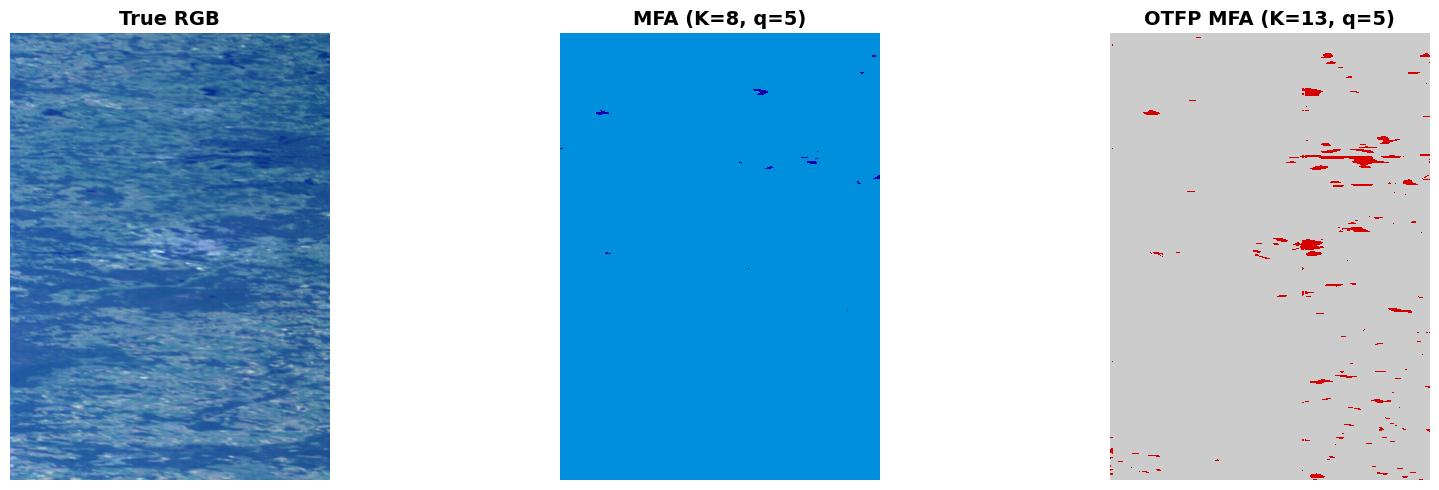

In [6]:
NUM_TEST_FILES = 3
num_test_files = min(NUM_TEST_FILES, len(test_data_dir))
print(f"Using {num_test_files} files for testing.")

# Create the figure grid: h rows (images), w columns (1 RGB + num_models)
h = num_test_files
w = 3

# Scale figure size dynamically based on the grid width/height
fig, axes = plt.subplots(h, w, figsize=(w * 6, h * 5))

# Ensure axes is a 2D array even if h=1 or w=1
if h == 1:
    axes = np.expand_dims(axes, axis=0)
if w == 1:
    axes = np.expand_dims(axes, axis=1)

# 2. Pre-load all models to avoid constantly reloading them inside the image loop
model_states = [mfa_state, otfp_mfa_state]
loaded_models = []
for state in model_states:
    
    # Extract params
    K = state['hyperparameters']['n_components']
    q = state['hyperparameters']['n_factors']
    n_features = state['hyperparameters']['n_features']
    
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(state['model_state_dict'])
    mfa_model.eval()
    
    # Deduce the preprocessing method from filename string (safest approach)
    model_type = "MFA"
    if state is otfp_mfa_state:
        model_type = "OTFP MFA"
    
    model_title = f"{model_type} (K={mfa_model.K}, q={mfa_model.q})"
    loaded_models.append({
        'model': mfa_model,
        'state': state, # FIX: Changed from mfa_state to state
        'title': model_title
    })
    
# 3. Loop over the test images
i = 0
# FIX: Sliced the directory list so it stops exactly at num_test_files
for file_path in test_data_dir[:num_test_files]:
    satobj = Hypso(file_path) 

    if satobj is None or satobj.l1b_cube is None:
        break
    
    image = satobj.l1b_cube.values.astype(np.float32)

    img_h, img_w, b = image.shape
    data_2d_full = image.reshape(-1, b)
    data_2d_full_tensor = torch.tensor(data_2d_full, dtype=torch.float32).to(device)

    # Get and Plot RGB Representation
    rgb_bands = [70, 50, 20]
    rgb_img = image[:, :, rgb_bands]
    # Normalize RGB for display
    rgb_img = (rgb_img - np.min(rgb_img)) / (np.max(rgb_img) - np.min(rgb_img))
    
    axes[i, 0].imshow(rgb_img, aspect='equal')
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title("True RGB", fontweight='bold', fontsize=14)

    # 4. Iterate through loaded models and plot classifications row-by-row
    for j, model_info in enumerate(loaded_models):
        model = model_info['model']
        
        # Pull the number of clusters (K) directly from the model
        current_K = model.K
        
        # Apply the specific preprocessing mathematically based on filename
        if Test_MFA_on_L2Normalized:
            norms = torch.norm(data_2d_full_tensor, p=2, dim=1, keepdim=True)
            epsilon = 1e-8
            processed_image = (data_2d_full_tensor / (norms + epsilon))
        else: # "None" or raw
            processed_image = data_2d_full_tensor.float()
                
        # Run Inference
        with torch.no_grad():
            log_resp, _ = model.e_step(processed_image)
            responsibilities = torch.exp(log_resp)
            new_cluster_ids = torch.argmax(responsibilities, dim=1)
            
        seg_map = new_cluster_ids.reshape(img_h, img_w).cpu().numpy()
        
        # Plot Classification Map
        # Use 'nipy_spectral' for enough distinct colors, and dynamically set vmax
        axes[i, j + 1].imshow(seg_map, cmap='nipy_spectral', vmin=0, vmax=current_K - 1, interpolation='nearest', aspect='equal')
        axes[i, j + 1].axis('off')
        
        # Add titles only to the top row to keep the grid clean
        if i == 0:
            axes[i, j + 1].set_title(model_info['title'], fontweight='bold', fontsize=14)
    i += 1

    del satobj, image, data_2d_full, data_2d_full_tensor

# Render the beautiful master plot
plt.tight_layout()
plt.show()

#### Classification

#### Loadings Plotting

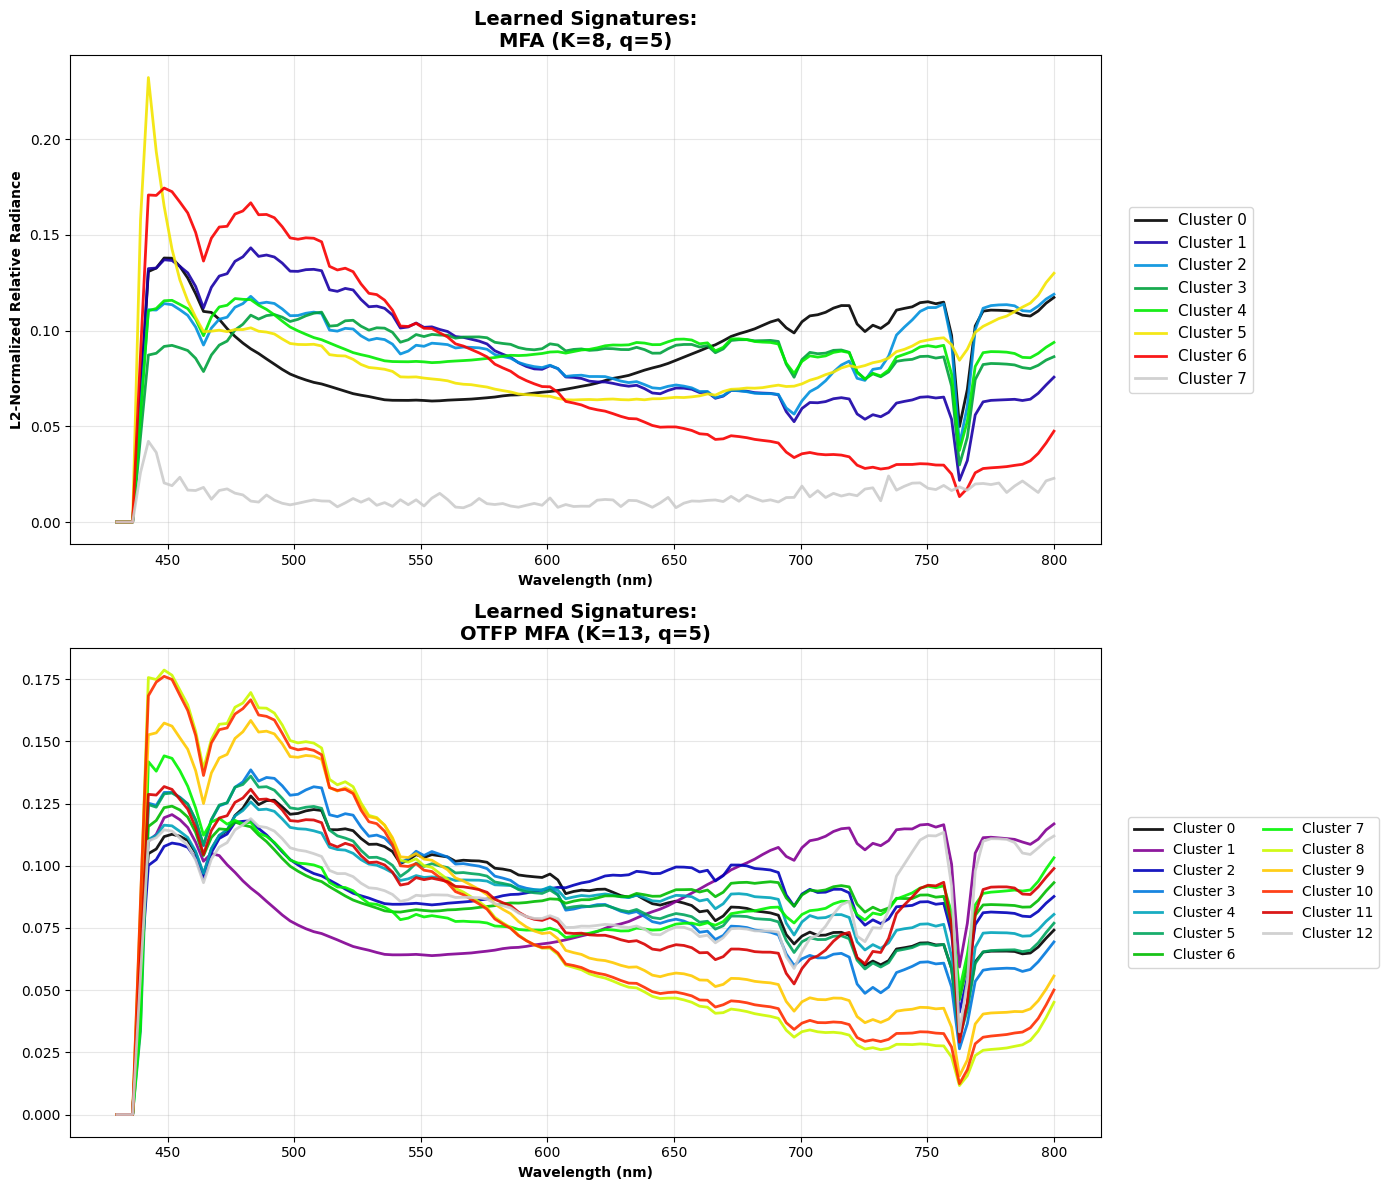

In [7]:
# 1. Define wavelengths
wavelengths_nm = np.linspace(430, 800, 120) 

# 2. Pre-load all models (Reusing your robust logic)
model_states = [mfa_state, otfp_mfa_state]
loaded_models = []
for state in model_states:
    
    # Extract params
    K = state['hyperparameters']['n_components']
    q = state['hyperparameters']['n_factors']
    n_features = state['hyperparameters']['n_features']
    
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(state['model_state_dict'])
    mfa_model.eval()
    
    # Deduce the preprocessing method from filename string
    model_type = "MFA"
    if state is otfp_mfa_state:
        model_type = "OTFP MFA"
    
    model_title = f"{model_type} (K={mfa_model.K}, q={mfa_model.q})"
    loaded_models.append({
        'model': mfa_model,
        'title': model_title
    })

# 3. Create the figure grid: 1 row, num_models columns
num_models = len(loaded_models)
fig, axes = plt.subplots(num_models, 1, figsize=(num_models * 7, 12))

# Ensure axes is an iterable array even if there is only 1 model
if num_models == 1:
    axes = [axes]

# 4. Iterate through loaded models and plot their signatures side-by-side
for j, model_info in enumerate(loaded_models):
    mfa_model = model_info['model']
    title = model_info['title']
    ax = axes[j]
    
    K = mfa_model.K
    
    # Extract means
    physical_means = mfa_model.mu.cpu().detach().numpy() 
    
    # Use nipy_spectral to match your image segmentation maps
    cmap = plt.get_cmap('nipy_spectral')
    
    for k in range(K):
        # Calculate dynamic color fraction to match the vmax/vmin scaling from earlier
        color_fraction = k / max(1, K - 1) 
        
        ax.plot(wavelengths_nm, physical_means[k], 
                label=f'Cluster {k}', 
                color=cmap(color_fraction), 
                linewidth=2.0, alpha=0.9)
        
    ax.set_title(f"Learned Signatures:\n{title}", fontweight='bold', fontsize=14)
    ax.set_xlabel("Wavelength (nm)", fontweight='bold')
    
    # Only label the Y-axis on the far left plot
    if j == 0:
        ax.set_ylabel("L2-Normalized Relative Radiance", fontweight='bold') 
    
    ax.grid(True, alpha=0.3)
    
    # Dynamically adjust legend columns based on K so it doesn't overflow
    if K > 20:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=3)
    elif K > 10:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=2)
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1)

# Render the plot
plt.tight_layout()
plt.show()

In [8]:
# From print()
wavelengths_nm = np.array([387.8, 391.4, 395.0, 398.5, 402.1, 405.6, 409.2, 412.7, 416.3, 419.8, 423.4, 426.9,
 430.4, 434.0, 437.5, 441.1, 444.6, 448.1, 451.7, 455.2, 458.7, 462.3, 465.8, 469.3,
 472.9, 476.4, 479.9, 483.4, 487.0, 490.5, 494.0, 497.5, 501.1, 504.6, 508.1, 511.6,
 515.1, 518.6, 522.1, 525.7, 529.2, 532.7, 536.2, 539.7, 543.2, 546.7, 550.2, 553.7,
 557.2, 560.7, 564.2, 567.7, 571.2, 574.7, 578.2, 581.6, 585.1, 588.6, 592.1, 595.6,
 599.1, 602.6, 606.0, 609.5, 613.0, 616.5, 620.0, 623.4, 626.9, 630.4, 633.9, 637.3,
 640.8, 644.3, 647.7, 651.2, 654.7, 658.1, 661.6, 665.1, 668.5, 672.0, 675.4, 678.9,
 682.3, 685.8, 689.3, 692.7, 696.2, 699.6, 703.1, 706.5, 709.9, 713.4, 716.8, 720.3,
 723.7, 727.2, 730.6, 734.0, 737.5, 740.9, 744.3, 747.8, 751.2, 754.6, 758.1, 761.5,
 764.9, 768.3, 771.8, 775.2, 778.6, 782.0, 785.4, 788.9, 792.3, 795.7, 799.1, 802.5])

